In [46]:
import ODESolve_slow as ODE
from constants import mN
import numpy as np
import thermodynamics as thermo
from constants import me, mpl, zeta3
import weakrates as weak
import expansion as ex
import nseabundance as nse
import derivatives as der
import matplotlib.pyplot as plt
import xy_reactions as xy
import xgamma_reactions as xg

In [48]:
MeVtoT9 = 11604525006.1657/10**9

In [50]:
cmgstoMeV = 1.52e-16

In [52]:
def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN

In [54]:
def tpga(T):
    T9 = T*MeVtoT9
    F = T9**(-2/3)*2.2e4*np.exp(-3.869/(T9**(1/3)))*((T9**(1/3))*0.108+1.+(T9**(2/3))*1.68+T9*1.26+(T9**(4/3))*0.551+(T9**(5/3))*1.06)

    return F*cmgstoMeV*mN

In [56]:

# nB = eta*(3/2)*zeta3*T**3
# gammaf=(f[12]*nb)/mN

In [58]:
PNGD_INDEX = 0
TPGA_INDEX = 1

In [60]:
def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))

#creates array of 12 dependent variables
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN
    

def f(a,y,p):
    T, t, eta, A = sep(y)
    nB = eta*(3/2)*zeta3*T**3
    Gamma_f = np.zeros(2)
    Gamma_f[PNGD_INDEX] = pngd(T)*nB
    Gamma_f[TPGA_INDEX] = tpga(T)*nB
    A_NSE = nse.nse(T, eta, A[nse.P_INDEX], A[nse.N_INDEX])
    Gamma_r = np.zeros(len(Gamma_f))
    Gamma_r[PNGD_INDEX] = Gamma_f[PNGD_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
    Gamma_r[TPGA_INDEX] = Gamma_f[TPGA_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
  
    der=np.zeros(3)
    d=np.zeros(9)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(-1/2)
    der[2] = -3*eta*((1/T)*der[0]+(1/a))

    d[nse.P_INDEX] += A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.P_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.N_INDEX] -= A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.N_INDEX] += A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.N_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.N_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.H2_INDEX] += A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.H2_INDEX] -= A[nse.H2_INDEX]*Gammar
    d[nse.H3_INDEX] = 0
    d[nse.HE3_INDEX] = 0
    d[nse.HE4_INDEX] = 0
    d[nse.BE7_INDEX] = 0
    d[nse.LI7_INDEX] = 0
    d[nse.LI6_INDEX] = 0

    return depvar(der[0], der[1], der[2], d*der[1])

In [63]:
%%time
a0 = 0.1    
T0 = 10
t0 = 0
eta0 = (6.1e-10)*(11/4)
Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
Yn0 = 1-Yp0

y0 = depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
p=0
dx0=0.001

N_step = 1000
dN = 1

x_final = 100

a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

print(dx)



True
[1.00000000e-03 1.85438051e-04 1.81393759e-04 1.38251104e-04
 1.67778960e-04 1.76350897e-04 1.51738814e-04 1.56009756e-04
 1.52213010e-04 1.45375683e-04 1.45102692e-04 1.54106527e-04
 1.63836260e-04 1.62124166e-04 1.50632018e-04 1.44470657e-04
 1.53291235e-04 1.70491035e-04 1.75719730e-04 1.60278437e-04
 1.46382870e-04 1.69524498e-04 1.90388436e-04 1.78630091e-04
 1.53003008e-04 1.79589877e-04 1.96546675e-04 1.77333223e-04
 1.51582444e-04 1.85735163e-04 2.11171419e-04 1.90931938e-04
 1.72496917e-04 1.55628969e-04 1.62278063e-04 1.90644836e-04
 2.10533355e-04 1.91387043e-04 1.63078305e-04 1.98744379e-04
 2.24529291e-04 2.03166000e-04 1.84920587e-04 1.68073428e-04
 1.74883049e-04 2.03542256e-04 2.23557381e-04 2.04595915e-04
 1.76166633e-04 2.11803757e-04 2.37890502e-04 2.17228132e-04
 1.97822461e-04 1.81038924e-04 1.89434257e-04 2.19893784e-04
 2.39544180e-04 2.18437072e-04 1.89209742e-04 2.27551094e-04
 2.56668643e-04 2.31667311e-04 1.92594563e-04 2.40409892e-04
 2.74205363e-04 2.4

/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_12169/3082941040.py:29: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

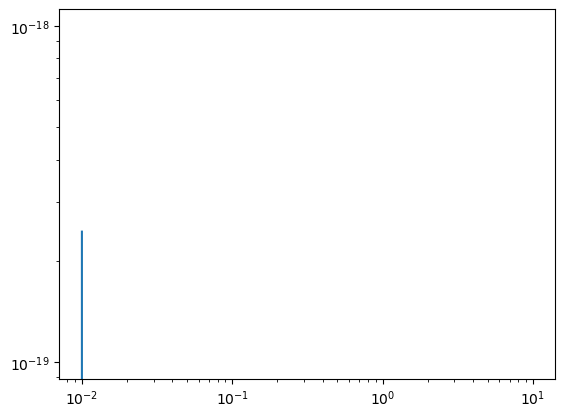

<Figure size 640x480 with 0 Axes>

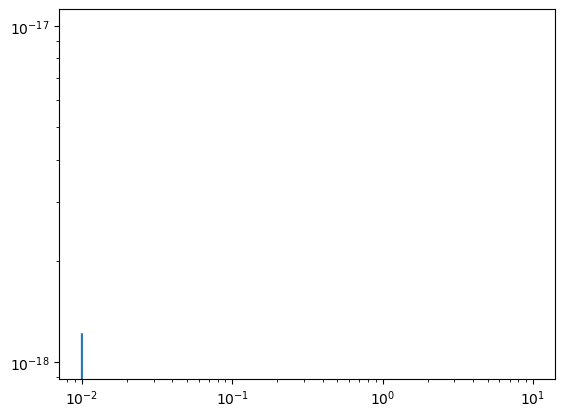

<Figure size 640x480 with 0 Axes>

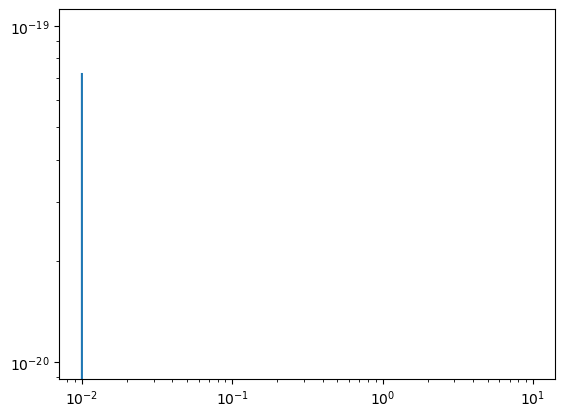

<Figure size 640x480 with 0 Axes>

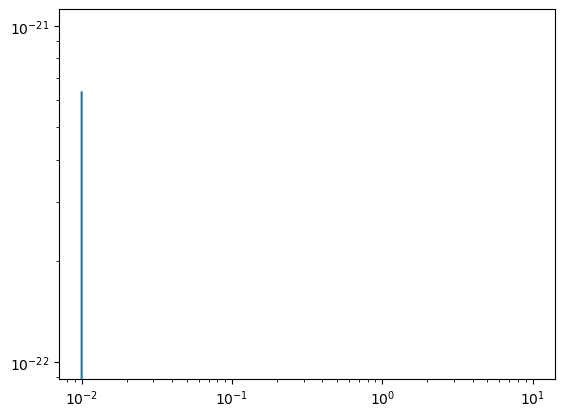

<Figure size 640x480 with 0 Axes>

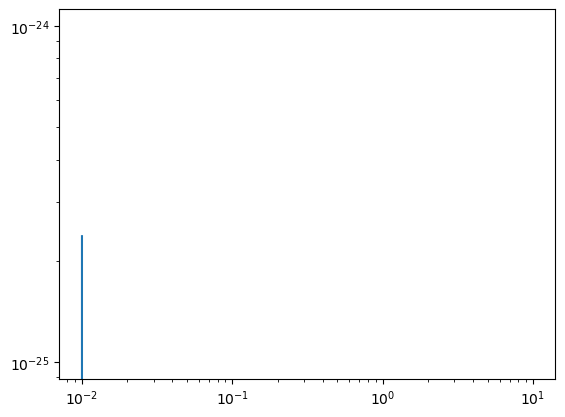

<Figure size 640x480 with 0 Axes>

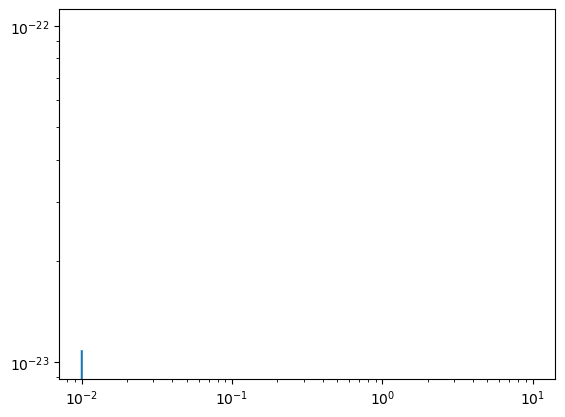

<Figure size 640x480 with 0 Axes>

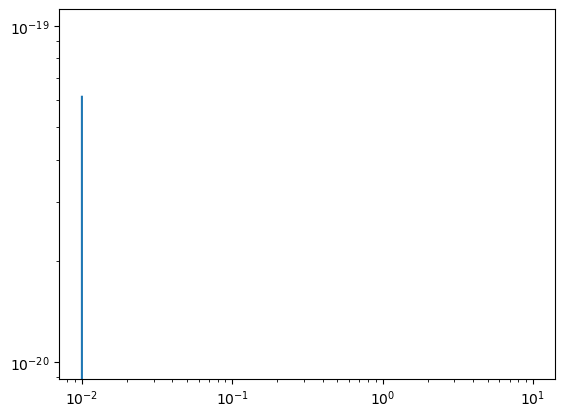

<Figure size 640x480 with 0 Axes>

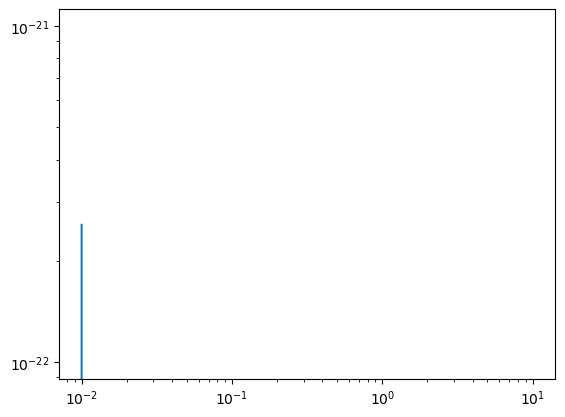

<Figure size 640x480 with 0 Axes>

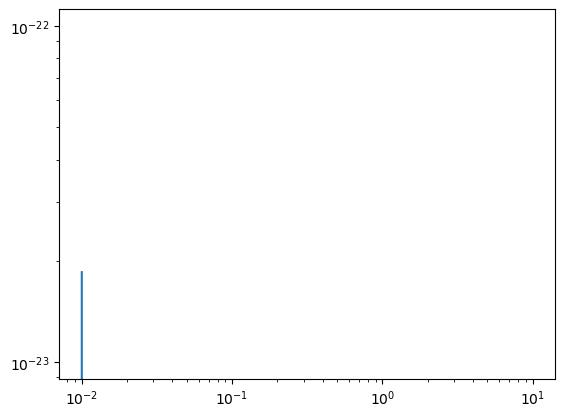

<Figure size 640x480 with 0 Axes>

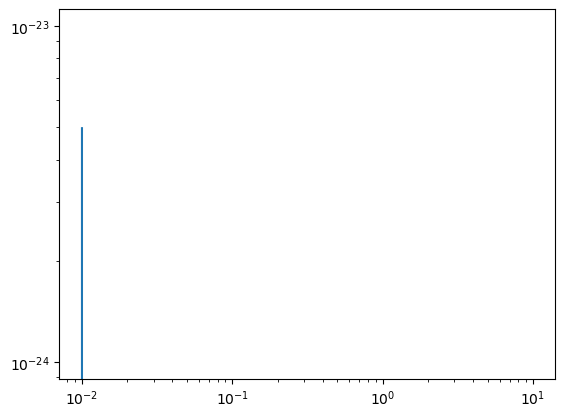

<Figure size 640x480 with 0 Axes>

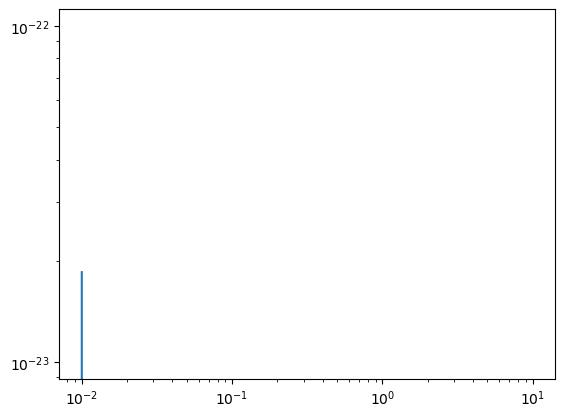

<Figure size 640x480 with 0 Axes>

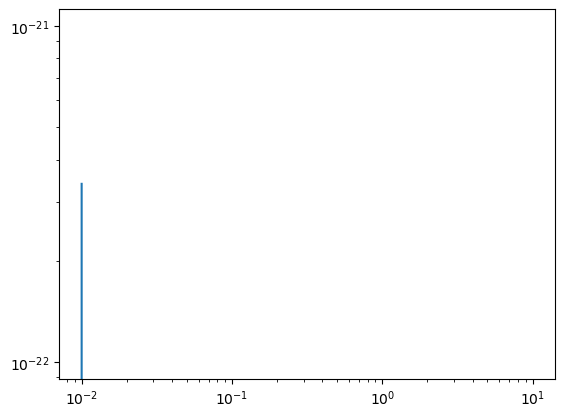

<Figure size 640x480 with 0 Axes>

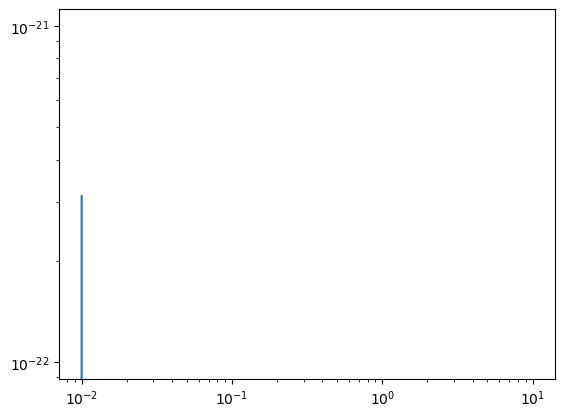

<Figure size 640x480 with 0 Axes>

In [90]:
T = y[:,0]
eta = y[:,2]

Gamma_f_XG = np.zeros((xg.Nrxn,len(a)))
Gamma_r_XG = np.zeros((xg.Nrxn,len(a)))
Gamma_f_XY = np.zeros((xy.Nrxn,len(a)))
Gamma_r_XY = np.zeros((xy.Nrxn,len(a)))
Tcm = 1/a
plt.figure()

for i in range(len(a)):
    Gamma_f_XG[:,i], Gamma_r_XG[:,i] = xg.Gammaxg(T[i], eta[i])

#for i in range(xg.Nrxn):
    #plt.figure()
    #plt.loglog(Tcm, Gamma_f_XG[i,:])
   # plt.title(i)
   # plt.figure()
  #  plt.loglog(Tcm, Gamma_r_XG[i,:])
 #   plt.title(i)


for j in range(len(a)):
    Gamma_f_XY[:,i], Gamma_r_XY[:,i] = xy.Gammaxy(T[i], eta[i])
  
for i in range(xy.Nrxn): 
    plt.figure()
    plt.loglog(Tcm, Gamma_f_XY[i,:])
    plt.figure()
   # plt.figure()
  #  plt.loglog(Tcm, Gamma_r_XY[i,:])
 #   plt.title(i)

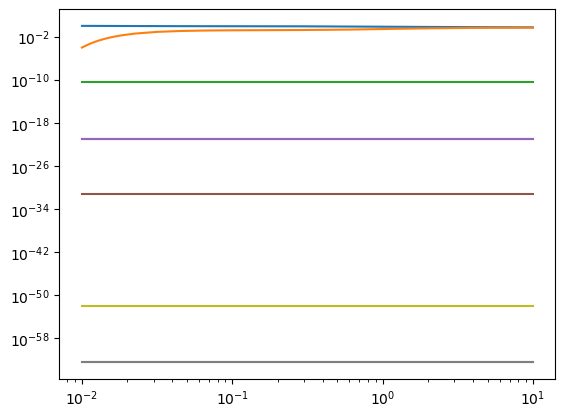

In [66]:
plt.figure()
Tcm=1/a
YP = np.zeros(len(a))
YN = np.zeros(len(a)) 
Y2H = np.zeros(len(a)) 
Y3H = np.zeros(len(a)) 
Y3HE = np.zeros(len(a)) 
Y4HE = np.zeros(len(a)) 
Y7BE = np.zeros(len(a)) 
Y7LI = np.zeros(len(a)) 
Y6LI = np.zeros(len(a)) 
nseval=np.zeros((9,len(a)))
    
for i in range(len(a)):
    
    YP[i] = y[i,3]
    YN[i] = y[i,4]
    Y2H[i] = y[i,5]
    Y3H[i] = y[i,6]
    Y3HE[i] = y[i,7]
    Y4HE[i] = y[i,8]
    Y7BE[i] = y[i,9]
    Y7LI[i] = y[i,10]
    Y6LI[i] = y[i,11]

    nseval[:,i] = nse.nse(y[i,0] , y[i,2] , y[i,3] , y[i,4])

plt.loglog(Tcm,YP)
plt.loglog(Tcm,YN)
plt.loglog(Tcm,Y2H)
plt.loglog(Tcm,Y3H )
plt.loglog(Tcm,Y3HE )
plt.loglog(Tcm,Y4HE )
plt.loglog(Tcm, Y7BE)
plt.loglog(Tcm,Y7LI )
plt.loglog(Tcm,Y6LI )
#plt.loglog(Tcm, nseval[2,:])



#for i in range():
   # plt.loglog(Tcm, nseval[i,:])
    #plt.ylim(10e-55,10e5)
#der.f(a0,y0,2)

In [67]:
print (xy.ddpt(T))


[-1.48622273e-04 -1.48148967e-04 -1.47534677e-04 -1.47126561e-04
 -1.46672250e-04 -1.46123269e-04 -1.45651893e-04 -1.45159614e-04
 -1.44655652e-04 -1.44166065e-04 -1.43700407e-04 -1.43237499e-04
 -1.42747909e-04 -1.42229701e-04 -1.41719220e-04 -1.41246975e-04
 -1.40795892e-04 -1.40319232e-04 -1.39791451e-04 -1.39250072e-04
 -1.38807790e-04 -1.38360564e-04 -1.37844876e-04 -1.37268568e-04
 -1.36829508e-04 -1.36370368e-04 -1.35833883e-04 -1.35249744e-04
 -1.34822966e-04 -1.34376342e-04 -1.33831588e-04 -1.33286282e-04
 -1.32731942e-04 -1.32233576e-04 -1.31785928e-04 -1.31321148e-04
 -1.30777706e-04 -1.30180793e-04 -1.29743622e-04 -1.29285468e-04
 -1.28729805e-04 -1.28176557e-04 -1.27614554e-04 -1.27105655e-04
 -1.26645281e-04 -1.26168427e-04 -1.25616200e-04 -1.25013084e-04
 -1.24561389e-04 -1.24090714e-04 -1.23527706e-04 -1.22962676e-04
 -1.22391700e-04 -1.21874547e-04 -1.21403606e-04 -1.20913202e-04
 -1.20346970e-04 -1.19733811e-04 -1.19272173e-04 -1.18792800e-04
 -1.18219385e-04 -1.17576

In [68]:
print(T)


[10.          9.98579983  9.96734506  9.95506867  9.94138801  9.92483586
  9.91060537  9.89572579  9.88047391  9.86563847  9.85151097  9.8374503
  9.82256103  9.80678106  9.79121584  9.77679817  9.76301009  9.74842264
  9.73224956  9.71563655  9.70204695  9.68828933  9.67240545  9.65462868
  9.64106712  9.62686832  9.6102555   9.59213971  9.57888608  9.56499968
  9.54803938  9.53103664  9.51372616  9.49814105  9.48412371  9.46955151
  9.45248914  9.4337181   9.41995053  9.40550396  9.38795767  9.37046016
  9.35265755  9.33651242  9.32188649  9.30671655  9.28912268  9.26987525
  9.25543802  9.24037387  9.22232716  9.20418552  9.18582213  9.16916284
  9.15396983  9.13812609  9.11980346  9.09992693  9.08493779  9.06935043
  9.05067516  9.02970231  9.01499466  8.99937214  8.97994685  8.96083753
  8.94125307  8.92347954  8.9074958   8.89102185  8.87184669  8.85064079
  8.83475485  8.81814483  8.79831371  8.77844191  8.75835119  8.74003078
  8.72321202  8.70566986  8.68551578  8.66376791  8.